# ANALISIS SENTIMEN PERSEPSI MASYARAKAT TERHADAP ASURANSI SYARIAH DI SISIAL MEDIA X

In [ ]:
# Import Library

import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Membaca & membukan data dalam bentuk excel

df = pd.read_excel("/content/datascrapingpersepsiasuransisyariah_.xlsx")
df

In [ ]:
# Mengambil kolom full_text (tweet)

df = df[['full_text']]
df

,full_text
0,Ada dong. Aku jual dan pake buat sendiri asura...
1,Asuransi Syariah Punya Potensi Besar tapi Pene...
2,@stupidmacchiato Kok riba ya wkwkwk kalopun ma...
3,Asuransi Konvensional dan Takaful (Asuransi Sy...
4,Assalamu'alaikum Sahabat Taka!\n\nMasih bingun...
...,...
995,"Hidup memang bukan perlombaan, tetapi dalam ur..."
996,Selamat Milad @TokioMarine_ID ke-47 Tahun. sem...
997,Seri SBSN yang akan dilelang adalah seri SPN-S...
998,@gouramibistro @ipoksamidub @yusufgunawan @Sen...


# 1. CLEANING DATA

In [ ]:
# Melihat jumlah baris & kolom

df.shape

(1000, 1)

In [ ]:
# Menghapus data yang duplikat

df = df.drop_duplicates(subset=['full_text'])
df.shape

(997, 1)

In [ ]:
# Melihat data duplikat

df.duplicated().sum()

np.int64(0)

In [ ]:
# Menghapus baris yang tidak ada nilainya (kosong)

df = df.dropna()

In [ ]:
# Melihat baris yang tidak memiliki nilai (kosong)

df.isnull().sum()

,0
full_text,0


In [ ]:
# Meliah julam baris dan kolom

df.shape

(997, 1)

In [ ]:
# Menghapus teks tweet dari elemen yang tidak memiliki nilai (value), seperti mention, hastag, link dsb.

def clean_twetter_text(text):
  text = re.sub(r'@[A-Za-z0-9_]+', '', text)
  text = re.sub(r'#\w+', '', text)
  text = re.sub(r'RT[\s]+', '', text)
  text = re.sub(r'https?://\S+', '', text)

  text = re.sub(r'[^A-Za-z0-9 ]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()

  return text

df['full_text'] = df['full_text'].astype(str).apply(clean_twetter_text)

In [ ]:
# Melihat data hasil cleaning data

df[['full_text']]

,full_text
0,Ada dong Aku jual dan pake buat sendiri asuran...
1,Asuransi Syariah Punya Potensi Besar tapi Pene...
2,Kok riba ya wkwkwk kalopun mau pake alasan sya...
3,Asuransi Konvensional dan Takaful Asuransi Sya...
4,Assalamualaikum Sahabat TakaMasih bingung apa ...
...,...
995,Hidup memang bukan perlombaan tetapi dalam uru...
996,Selamat Milad ke47 Tahun semoga sukses selalu ...
997,Seri SBSN yang akan dilelang adalah seri SPNS ...
998,Baru kali ini aku ada yang menyapa Dan aku lan...


In [ ]:
# Mengubah semua text (tweet) menjadi huruf kecill

df['full_text'] = df['full_text'].str.lower()

In [ ]:
# Melihat hasilnya

df

,full_text
0,ada dong aku jual dan pake buat sendiri asuran...
1,asuransi syariah punya potensi besar tapi pene...
2,kok riba ya wkwkwk kalopun mau pake alasan sya...
3,asuransi konvensional dan takaful asuransi sya...
4,assalamualaikum sahabat takamasih bingung apa ...
...,...
995,hidup memang bukan perlombaan tetapi dalam uru...
996,selamat milad ke47 tahun semoga sukses selalu ...
997,seri sbsn yang akan dilelang adalah seri spns ...
998,baru kali ini aku ada yang menyapa dan aku lan...


# 2. PREPROCESSING

*   Tokenize
*   Normalisasi

*   Stopword Removal
*   Stemming





In [ ]:
# Tokenize

df['sebelum_tokenize'] = df['full_text']
df['hasil_tokenize'] = df['full_text'].apply(lambda x: str(x).split())

df = df[["sebelum_tokenize","hasil_tokenize"]]
df

,sebelum_tokenize,hasil_tokenize
0,ada dong aku jual dan pake buat sendiri asuran...,"[ada, dong, aku, jual, dan, pake, buat, sendir..."
1,asuransi syariah punya potensi besar tapi pene...,"[asuransi, syariah, punya, potensi, besar, tap..."
2,kok riba ya wkwkwk kalopun mau pake alasan sya...,"[kok, riba, ya, wkwkwk, kalopun, mau, pake, al..."
3,asuransi konvensional dan takaful asuransi sya...,"[asuransi, konvensional, dan, takaful, asurans..."
4,assalamualaikum sahabat takamasih bingung apa ...,"[assalamualaikum, sahabat, takamasih, bingung,..."
...,...,...
995,hidup memang bukan perlombaan tetapi dalam uru...,"[hidup, memang, bukan, perlombaan, tetapi, dal..."
996,selamat milad ke47 tahun semoga sukses selalu ...,"[selamat, milad, ke47, tahun, semoga, sukses, ..."
997,seri sbsn yang akan dilelang adalah seri spns ...,"[seri, sbsn, yang, akan, dilelang, adalah, ser..."
998,baru kali ini aku ada yang menyapa dan aku lan...,"[baru, kali, ini, aku, ada, yang, menyapa, dan..."


In [ ]:
# Normalisasi Kata

normalisasi = {

    # Kata ganti
    "gw":"saya",
    "gue":"saya",
    "gua":"saya",
    "sy":"saya",
    "akuu":"aku",
    "km":"kamu",
    "lu":"kamu",
    "loe":"kamu",

    # Negasi
    "ga":"tidak",
    "gak":"tidak",
    "gk":"tidak",
    "nggak":"tidak",
    "enggak":"tidak",
    "tdk":"tidak",


    # Kata umum
    "aja":"saja",
    "udh":"sudah",
    "udah":"sudah",
    "blm":"belum",
    "bgt":"banget",
    "bngt":"banget",
    "bangettt":"banget",
    "krn":"karena",
    "karna":"karena",
    "trs":"terus",
    "tp":"tetapi",
    "tpi":"tetapi",
    "sm":"sama",
    "dr":"dari",
    "dgn":"dengan",
    "utk":"untuk",
    "yg":"yang",
    "org":"orang",
    "pdhl":"padahal",
    "kalo":"kalau",
    "klo":"kalau",
    "emg":"memang",
    "emang":"memang",

    # Penulisan umum
    "dlm":"dalam",
    "jd":"jadi",
    "jg":"juga",
    "sdh":"sudah",
    "spy":"supaya",
    "trs":"terus",
    "krg":"kurang",

    # Bahasa Inggris
    "good":"baik",
    "bad":"buruk",
    "nice":"bagus",
    "recommend":"rekomendasi",
    "recommended":"direkomendasikan",
    "worthit":"bermanfaat",
    "worth":"bermanfaat",
    "support":"dukungan",
    "help":"bantu",

    # Kata yang sering muncul
    "ok":"baik",
    "oke":"baik",
    "sip":"baik",
    "mantap":"bagus",
    "mantul":"bagus",
    "jelek":"buruk",
    "ribet":"rumit",
    "lemot":"lambat",
    "gajelas":"tidak jelas",
    "scam":"penipuan",
    "pake" : "pakai"
}


def normalisasi_teks(tokens):
    if isinstance(tokens, list):
        hasil = [normalisasi.get(k.lower(), k.lower()) for k in tokens]
        return hasil
    else:
        tokens = str(tokens).lower().split()
        hasil = [normalisasi.get(k, k) for k in tokens]
        return hasil

# Simpan data asli
df["sebelum_normalisasi"] = df["hasil_tokenize"]

# Normalisasi
df["hasil_normalisasi"] = df["hasil_tokenize"].apply(normalisasi_teks)


df = df[['sebelum_normalisasi', 'hasil_normalisasi']]
df

,sebelum_normalisasi,hasil_normalisasi
0,"[ada, dong, aku, jual, dan, pake, buat, sendir...","[ada, dong, aku, jual, dan, pakai, buat, sendi..."
1,"[asuransi, syariah, punya, potensi, besar, tap...","[asuransi, syariah, punya, potensi, besar, tap..."
2,"[kok, riba, ya, wkwkwk, kalopun, mau, pake, al...","[kok, riba, ya, wkwkwk, kalopun, mau, pakai, a..."
3,"[asuransi, konvensional, dan, takaful, asurans...","[asuransi, konvensional, dan, takaful, asurans..."
4,"[assalamualaikum, sahabat, takamasih, bingung,...","[assalamualaikum, sahabat, takamasih, bingung,..."
...,...,...
995,"[hidup, memang, bukan, perlombaan, tetapi, dal...","[hidup, memang, bukan, perlombaan, tetapi, dal..."
996,"[selamat, milad, ke47, tahun, semoga, sukses, ...","[selamat, milad, ke47, tahun, semoga, sukses, ..."
997,"[seri, sbsn, yang, akan, dilelang, adalah, ser...","[seri, sbsn, yang, akan, dilelang, adalah, ser..."
998,"[baru, kali, ini, aku, ada, yang, menyapa, dan...","[baru, kali, ini, aku, ada, yang, menyapa, dan..."


In [ ]:
# Menginstall Package (Library) sastrawi

!pip install Sastrawi

In [ ]:
# Stopword

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Stopword bawaan Sastrawi
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

# Tambahan stopword sesuai data tweet asuransi syariah
custom_stopwords = [

    "aja","ajalah","ajaa","ajah",
    "aku","akunya","akuh",
    "anda","ane","gw","gua","gue","gua","kami","kita","kamu","kau","loe","lu",
    "dia","beliau","mereka","nya",

    "yang","yg","ygk","utk","untuk","dengan","dg","dgn",
    "dan","atau","serta","karena","karna","krn","sebab",
    "agar","supaya","jadi","jadinya","makanya",
    "kalau","kalo","kl","bila","jika","apabila",
    "meski","meskipun","walau","walaupun",

    "di","ke","dari","dr","pada","dalam","luar",
    "atas","bawah","antara","hingga","sampai","sejak",
    "oleh","kepada","terhadap","tentang","mengenai",

    "ini","itu","ituh","nih","tuh","sini","situ","sana",
    "apa","siapa","mana","kapan","kenapa","mengapa","bagaimana",

    "iya","ya","yah","yaa","iyah","ok","oke","okay",
    "sip","nah","noh","kan","pun","lah","deh","dong","kok","loh",

    "gak","ga","gk","nggak","enggak","tdk","tidak","tak",
    "belum","udah","sudah","udahh","blm",

    "aja","saja","cuma","cm","hanya","doang",
    "masih","lagi","sedang","pernah","sempat",

    "lebih","kurang","cukup","banyak","sedikit",
    "semua","seluruh","setiap","masing","beberapa",

    "bgt","banget","amat","sekali","terlalu",

    "rt","via","dll","dst",
    "nihh","dongg","wkwk","wk","haha","hehe","hihi",
    "eh","oh","ah","ih","yah",

    "gitu","gini","begitu","begini",
    "kayak","kaya","seperti","ibarat",
    "biar","buat","bikin","agar",

    "udah","dah","udahdeh","yahudah",

    "www","http","https","co","com","id",
    "amp","link","url",

    "min","admin","gan","sis","bro","bos","kak",

    "yaudah","gapapa","gpp","okelah",
    "tetep","tetap","malah","bahkan",

    "sih","punya","aja","lahh","donglah"
]
# Gabungkan stopword
stopwords = list(set(stopwords + custom_stopwords))

def remove_stopwords(words):
    return [word for word in words if word not in stopwords]

# Sesudah Stopword
df["hasil_stopword"] = df["hasil_normalisasi"].apply(remove_stopwords)

# Sebelum Stopword
df["sebelum_stopword"] = df["hasil_normalisasi"]

# Menampilkan Hasil
df = df[["sebelum_stopword","hasil_stopword"]]
df

/tmp/ipykernel_669/324879640.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hasil_stopword"] = df["hasil_normalisasi"].apply(remove_stopwords)


,sebelum_stopword,hasil_stopword
0,"[ada, dong, aku, jual, dan, pakai, buat, sendi...","[jual, pakai, sendiri, asuransi, kesehatan, tr..."
1,"[asuransi, syariah, punya, potensi, besar, tap...","[asuransi, syariah, potensi, besar, penetrasi,..."
2,"[kok, riba, ya, wkwkwk, kalopun, mau, pakai, a...","[riba, wkwkwk, kalopun, mau, pakai, alasan, sy..."
3,"[asuransi, konvensional, dan, takaful, asurans...","[asuransi, konvensional, takaful, asuransi, sy..."
4,"[assalamualaikum, sahabat, takamasih, bingung,...","[assalamualaikum, sahabat, takamasih, bingung,..."
...,...,...
995,"[hidup, memang, bukan, perlombaan, tetapi, dal...","[hidup, memang, bukan, perlombaan, urusan, keb..."
996,"[selamat, milad, ke47, tahun, semoga, sukses, ...","[selamat, milad, ke47, tahun, semoga, sukses, ..."
997,"[seri, sbsn, yang, akan, dilelang, adalah, ser...","[seri, sbsn, dilelang, seri, spns, surat, perb..."
998,"[baru, kali, ini, aku, ada, yang, menyapa, dan...","[baru, kali, menyapa, langsung, gampang, curig..."


In [ ]:
# Mengubah hasl stopword untuk tahap stemming

df['hasil_stopword_string'] = df['hasil_stopword'].apply(lambda x: ' '.join(x))
df = df[['hasil_stopword', 'hasil_stopword_string']]
df

/tmp/ipykernel_669/1348201783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hasil_stopword_string'] = df['hasil_stopword'].apply(lambda x: ' '.join(x))


,hasil_stopword,hasil_stopword_string
0,"[jual, pakai, sendiri, asuransi, kesehatan, tr...",jual pakai sendiri asuransi kesehatan tradisio...
1,"[asuransi, syariah, potensi, besar, penetrasi,...",asuransi syariah potensi besar penetrasi 1 persen
2,"[riba, wkwkwk, kalopun, mau, pakai, alasan, sy...",riba wkwkwk kalopun mau pakai alasan syariah g...
3,"[asuransi, konvensional, takaful, asuransi, sy...",asuransi konvensional takaful asuransi syariah...
4,"[assalamualaikum, sahabat, takamasih, bingung,...",assalamualaikum sahabat takamasih bingung perb...
...,...,...
995,"[hidup, memang, bukan, perlombaan, urusan, keb...",hidup memang bukan perlombaan urusan kebaikan ...
996,"[selamat, milad, ke47, tahun, semoga, sukses, ...",selamat milad ke47 tahun semoga sukses selalu ...
997,"[seri, sbsn, dilelang, seri, spns, surat, perb...",seri sbsn dilelang seri spns surat perbendahar...
998,"[baru, kali, menyapa, langsung, gampang, curig...",baru kali menyapa langsung gampang curiga asur...


In [ ]:
# Menyimpan data hasil stopword ke dalam format excel (Opsional)

df.to_excel('hasil_processed_tidak_pakai_stemming.xlsx', index=False)

In [ ]:
# Melakukan Stemming

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(teks):
    return stemmer.stem(str(teks))

# Sebelum Stemming
df['sebelum_stemming'] = df['hasil_stopword']

# Melakukan Stemming/Hasil
df["hasil_stemming"] = df["hasil_stopword"].apply(stemming)

In [ ]:
# Melihat hasil stemming

df = df[['sebelum_stemming', 'hasil_stemming']]
df

,sebelum_stemming,hasil_stemming
0,"[jual, pakai, sendiri, asuransi, kesehatan, tr...",jual pakai sendiri asuransi sehat tradisional ...
1,"[asuransi, syariah, potensi, besar, penetrasi,...",asuransi syariah potensi besar penetrasi 1 persen
2,"[riba, wkwkwk, kalopun, mau, pakai, alasan, sy...",riba wkwkwk kalo mau pakai alas syariah gharar...
3,"[asuransi, konvensional, takaful, asuransi, sy...",asuransi konvensional takaful asuransi syariah...
4,"[assalamualaikum, sahabat, takamasih, bingung,...",assalamualaikum sahabat takamasih bingung beda...
...,...,...
995,"[hidup, memang, bukan, perlombaan, urusan, keb...",hidup memang bukan lomba urus baik masingmasin...
996,"[selamat, milad, ke47, tahun, semoga, sukses, ...",selamat milad ke47 tahun moga sukses selalu aa...
997,"[seri, sbsn, dilelang, seri, spns, surat, perb...",seri sbsn lelang seri spns surat bendahara neg...
998,"[baru, kali, menyapa, langsung, gampang, curig...",baru kali sapa langsung gampang curiga asurans...


# 3. LABELING

In [ ]:
# Mengistall package (Library) untuk labeling

!pip install tweet-preprocessor
!pip install textblob
!pip install wordcloud
!pip install nltk

In [ ]:
# Mengimport library untuk klasifikasi teks

import preprocessor as p
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# Membaca & melihat data hasil preprocessing

df = pd.read_excel('/content/hasil_processed_pakai_stemming.xlsx')
df.head()

,sebelum_stemming,hasil_stemming
0,"['jual', 'pakai', 'sendiri', 'asuransi', 'kese...",jual pakai sendiri asuransi sehat tradisional ...
1,"['asuransi', 'syariah', 'potensi', 'besar', 'p...",asuransi syariah potensi besar penetrasi 1 persen
2,"['riba', 'wkwkwk', 'kalopun', 'mau', 'pakai', ...",riba wkwkwk kalo mau pakai alas syariah gharar...
3,"['asuransi', 'konvensional', 'takaful', 'asura...",asuransi konvensional takaful asuransi syariah...
4,"['assalamualaikum', 'sahabat', 'takamasih', 'b...",assalamualaikum sahabat takamasih bingung beda...


In [ ]:
# Membaca & melihat kamus positive & negative

positive = pd.read_csv("/content/positive.tsv", sep="\t")
negative = pd.read_csv("/content/negative.tsv", sep="\t")

In [ ]:
# Melihat isi dari kamus Positive

positive.head()

,word,weight
0,hai,3
1,merekam,2
2,ekstensif,3
3,paripurna,1
4,detail,2


In [ ]:
# Melihat isi dari kamus Negative

negative.head()

,word,weight
0,putus tali gantung,-2
1,gelebah,-2
2,gobar hati,-2
3,tersentuh (perasaan),-1
4,isak,-5


In [ ]:
# Menggabungkan kamus positiv & negativ menjadi satu lexicond

positive_dict = dict(zip(positive.word, positive.weight))
negative_dict = dict(zip(negative.word, negative.weight))

lexicon = {}

lexicon.update(positive_dict)
lexicon.update(negative_dict)

In [ ]:
# Menambahkan kamus kata yang berkaitan dengan asuransi syariah

domain_lexicon = {

    # Positif
    "tabarru": 3,
    "taawun": 3,
    "wakalah": 2,
    "mudharabah": 2,
    "musyarakah": 2,
    "amanah": 3,
    "halal": 2,
    "syariah": 1,
    "tolong": 2,
    "bermanfaat": 3,
    "terpercaya": 3,
    "transparan": 2,
    "sesuai": 2,

    # Negatif
    "klaim ditolak": -5,
    "gagal klaim": -5,
    "penipuan": -5,
    "scam": -5,
    "ribet": -2,
    "rumit": -2,
    "lama": -2,
    "mahal": -2,
    "tidak jelas": -3,
    "kecewa": -4,
    "bohong": -4
}

lexicon.update(domain_lexicon)

In [ ]:
# Menghitung score sentimen

def sentiment_score(text):

    score = 0

    words = text.split()

    for word in words:

        if word in lexicon:
            score += lexicon[word]

    return score

In [ ]:
#  Menentukan label sentimn dari masing-masing teks

def sentiment_label(text):

    score = sentiment_score(text)

    if score > 0:
        return "Positif"

    elif score < 0:
        return "Negatif"

    else:
        return "Netral"

In [ ]:
# Menghitung skor & label sentimen serta menyiapkan dataframe yang baru

df['hasil_stemming'] = df['hasil_stemming'].fillna('').astype(str)

df["score"] = df["hasil_stemming"].apply(sentiment_score)

df["label"] = df["hasil_stemming"].apply(sentiment_label)

In [ ]:
# mengubah naman kolom menjadi -> hasil_preprocessing

df = df.rename(columns={'hasil_stemming': 'hasil_preprocessing'})

In [ ]:
# Membaca & melihat hasil labeling dalam bentuk dataframe

df = df[["hasil_preprocessing", "score", "label"]]
df

,hasil_preprocessing,score,label
0,jual pakai sendiri asuransi sehat tradisional ...,-7,Negatif
1,asuransi syariah potensi besar penetrasi 1 persen,4,Positif
2,riba wkwkwk kalo mau pakai alas syariah gharar...,-7,Negatif
3,asuransi konvensional takaful asuransi syariah...,-9,Negatif
4,assalamualaikum sahabat takamasih bingung beda...,0,Netral
...,...,...,...
992,hidup memang bukan lomba urus baik masingmasin...,12,Positif
993,selamat milad ke47 tahun moga sukses selalu aa...,11,Positif
994,seri sbsn lelang seri spns surat bendahara neg...,-6,Negatif
995,baru kali sapa langsung gampang curiga asurans...,-7,Negatif


In [ ]:
# Menghitung kemunculan masing-masing sentimen

df['label'].value_counts()

,count
label,
Negatif,615
Positif,339
Netral,43


In [ ]:
# Menyimpan data hasil labeling ke dalam format excel

df.to_excel('sentiment_analysis_results.xlsx', index=False)

# 4. VISUALISASI

In [ ]:
# Membaca & melihat data hasil labeling


df = pd.read_excel('/content/sentiment_analysis_results.xlsx')
df

,hasil_preprocessing,score,label
0,jual pakai sendiri asuransi sehat tradisional ...,-7,Negatif
1,asuransi syariah potensi besar penetrasi 1 persen,4,Positif
2,riba wkwkwk kalo mau pakai alas syariah gharar...,-7,Negatif
3,asuransi konvensional takaful asuransi syariah...,-9,Negatif
4,assalamualaikum sahabat takamasih bingung beda...,0,Netral
...,...,...,...
992,hidup memang bukan lomba urus baik masingmasin...,12,Positif
993,selamat milad ke47 tahun moga sukses selalu aa...,11,Positif
994,seri sbsn lelang seri spns surat bendahara neg...,-6,Negatif
995,baru kali sapa langsung gampang curiga asurans...,-7,Negatif


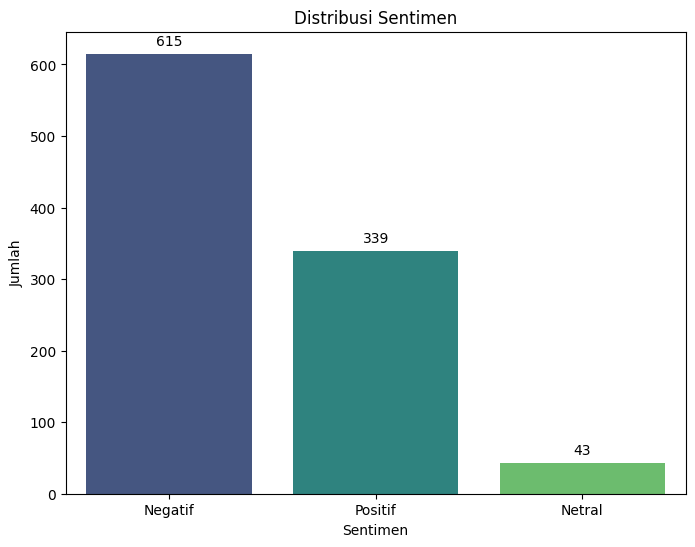

In [ ]:
# Membuat visualisasi grafik batang yang menampilkan dostribusi hasil sentimen

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='label', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

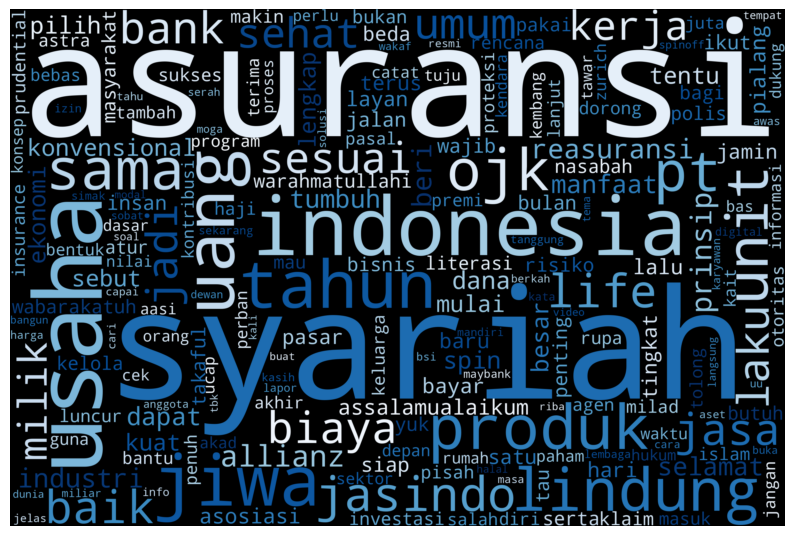

In [ ]:
# Membuat visualisasi wordcloud

from wordcloud import WordCloud, STOPWORDS

def plot_cloud (wordcloud):
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

# Ensure all values in 'hasil_preprocessing' are strings before joining
all_words = ' '.join([str(tweets) for tweets in df['hasil_preprocessing']])

wordcloud = WordCloud (
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate (all_words)

plot_cloud (wordcloud)

In [ ]:
# Menghitung frekuensi kemunculan tiap kata

from nltk.probability import FreqDist
import pandas as pd

# Gabungkan semua kata hasil stemming ke dalam satu list
all_stemmed_words = []
for text_list in df['hasil_preprocessing']:
    # Convert each item to string before splitting to handle potential float (NaN) values
    all_stemmed_words.extend(str(text_list).split())

# Hitung frekuensi kata
fdist = FreqDist(all_stemmed_words)

# Konversi ke DataFrame untuk tampilan yang lebih baik
word_freq_df = pd.DataFrame(fdist.most_common(10), columns=['Kata', 'Frekuensi'])

print("Top 10 Kata Terbanyak:")
display(word_freq_df)

Top 10 Kata Terbanyak:


,Kata,Frekuensi
0,asuransi,1307
1,syariah,1219
2,usaha,277
3,indonesia,200
4,jiwa,147
5,uang,143
6,tahun,129
7,produk,113
8,lindung,104
9,sama,100
